In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")

In [2]:
df = pd.read_csv("master_orders.csv")
df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,...,8.72,2.0,voucher,1.0,18.59,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,...,22.76,1.0,boleto,1.0,141.46,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,...,19.22,1.0,credit_card,3.0,179.12,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,...,8.72,1.0,credit_card,1.0,28.62,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
4,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,...,27.36,1.0,credit_card,6.0,175.26,4.0,NaN,NaN,2017-07-27 00:00:00,2017-07-27 22:48:30


In [3]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]
for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        format="mixed",
        errors="coerce"
    )

In [4]:
#Creating Delivery metrics

In [5]:
#Delivery Time (Purchase → Customer Delivery)
df["delivery_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

In [6]:
#Delivery Delay (Estimated → Actual)
df["delivery_delay"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days

In [7]:
#Carrier Shipping Time
df["carrier_days"] = (
    df["order_delivered_customer_date"] -
    df["order_delivered_carrier_date"]
).dt.days

In [8]:
#Order Processing Time
df["processing_days"] = (
    df["order_approved_at"] -
    df["order_purchase_timestamp"]
).dt.days

In [9]:
df[[
    "delivery_days",
    "delivery_delay",
    "carrier_days",
    "processing_days"
]].describe()

,delivery_days,delivery_delay,carrier_days,processing_days
count,115722.000000,115722.000000,115721.000000,118966.000000
mean,12.022589,-12.048392,8.746995,0.274465
std,9.454922,10.163801,8.621201,0.980584
min,0.000000,-147.000000,-17.000000,0.000000
25%,6.000000,-17.000000,4.000000,0.000000
50%,10.000000,-13.000000,7.000000,0.000000
75%,15.000000,-7.000000,11.000000,0.000000
max,209.000000,188.000000,205.000000,187.000000


In [10]:
df[[
    "delivery_days",
    "delivery_delay",
    "carrier_days",
    "processing_days"
]].isnull().sum()

delivery_days      3421
delivery_delay     3421
carrier_days       3422
processing_days     177
dtype: int64

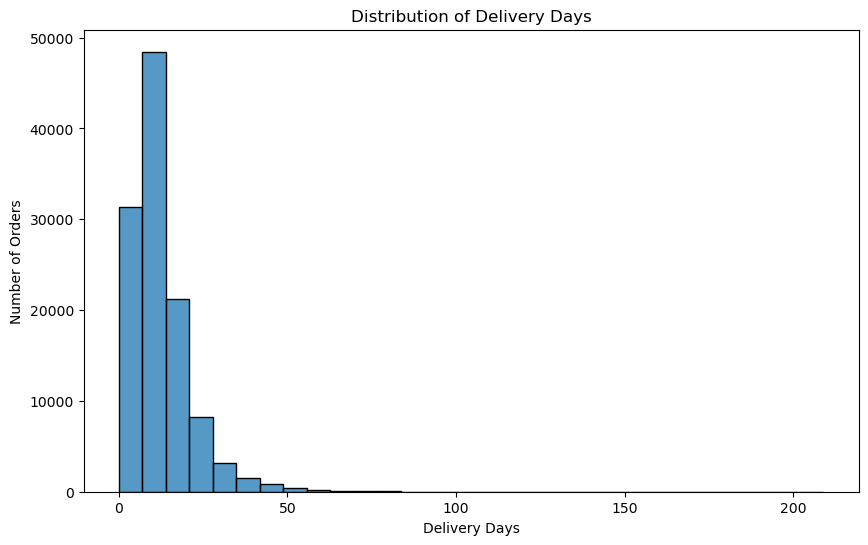

In [11]:
#Distribution of Delivery Time
plt.figure(figsize=(10,6))
sns.histplot(
    df["delivery_days"],
    bins=30
)
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

1) Majority of deliveries happen within one to two weeks.

2) Very long deliveries are relatively rare.

3) Presence of a long right tail indicates some delayed deliveries.

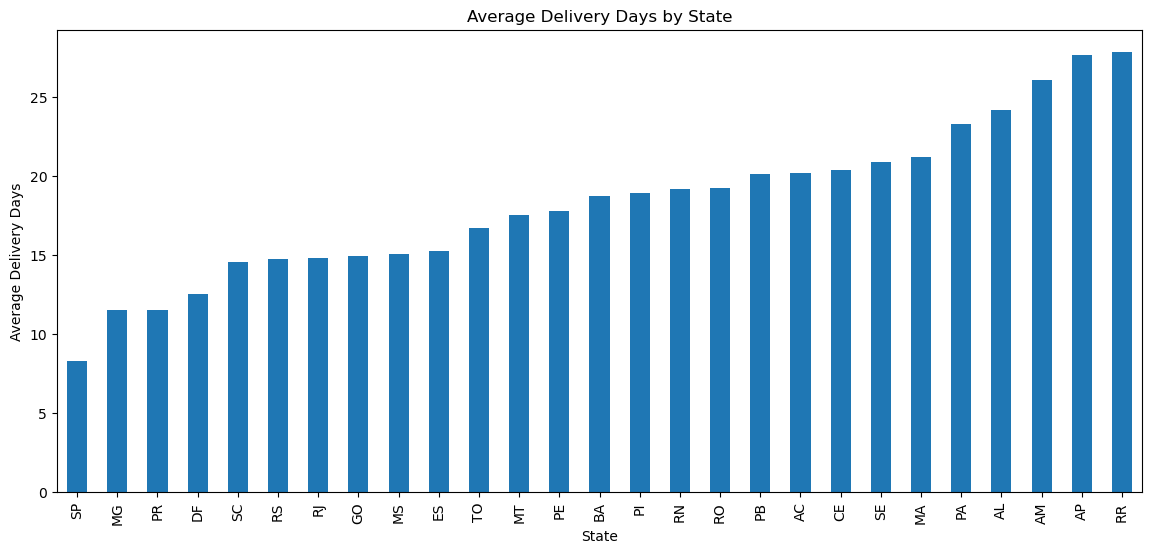

In [12]:
#2. Average Delivery Time by State
state_delivery = (
    df.groupby("customer_state")["delivery_days"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(14,6))
state_delivery.plot(kind="bar")
plt.title("Average Delivery Days by State")
plt.xlabel("State")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=90)
plt.show()

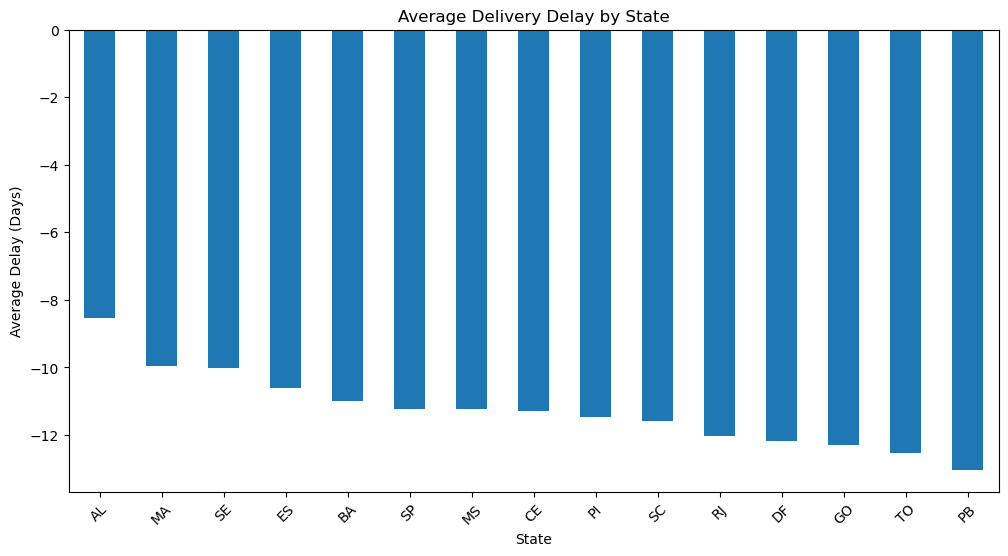

In [13]:
#3. Top 15 States with Highest Delivery Delay
delay_state = (
    df.groupby("customer_state")["delivery_delay"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
delay_state.plot(kind="bar")
plt.title("Average Delivery Delay by State")
plt.xlabel("State")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45)
plt.show()

In [14]:
#4. On-Time vs Delayed Deliveries
df["delivery_status"] = df["delivery_delay"].apply(
    lambda x: "Delayed" if x > 0 else "On Time"
)

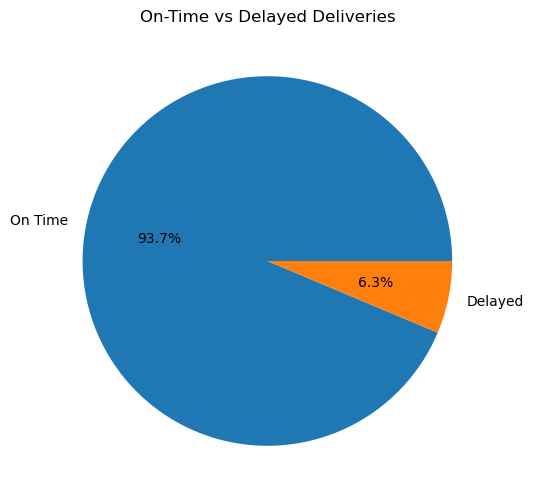

In [15]:
plt.figure(figsize=(6,6))
df["delivery_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("On-Time vs Delayed Deliveries")
plt.show()

1) A high percentage of on-time deliveries reflects strong logistics performance.

2) Delayed deliveries represent potential customer dissatisfaction.

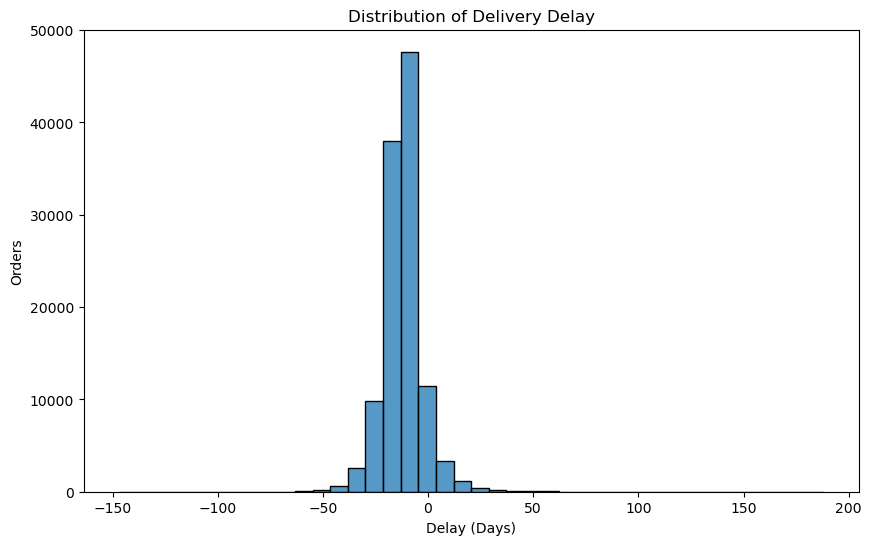

In [16]:
#5. Delivery Delay Distribution
plt.figure(figsize=(10,6))
sns.histplot(
    df["delivery_delay"],
    bins=40
)
plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay (Days)")
plt.ylabel("Orders")
plt.show()

1) Negative values indicate early deliveries.

2) Zero indicates on-time delivery.

3) Positive values represent late deliveries.  

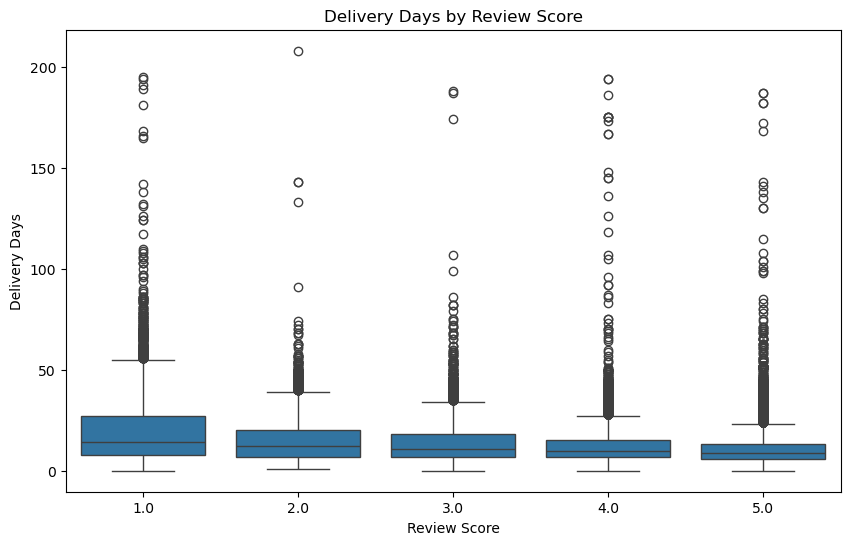

In [17]:
#6. Delivery Time vs Review Score
plt.figure(figsize=(10,6))
sns.boxplot(
    x="review_score",
    y="delivery_days",
    data=df
)
plt.title("Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.show()

1) Lower review scores are generally associated with longer delivery times.

2) Customers who receive faster deliveries tend to give higher ratings.

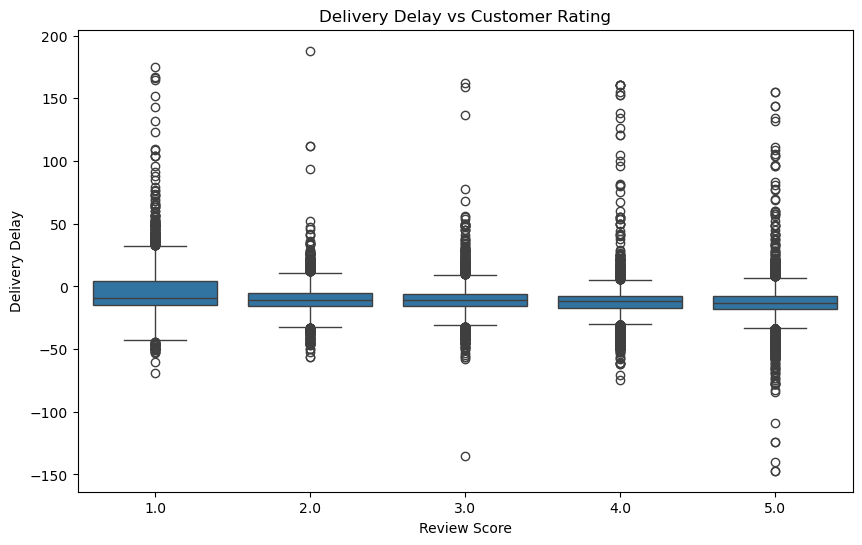

In [18]:
#7. Delivery Delay vs Review Score
plt.figure(figsize=(10,6))
sns.boxplot(
    x="review_score",
    y="delivery_delay",
    data=df
)
plt.title("Delivery Delay vs Customer Rating")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay")
plt.show()

1) Significant delivery delays often correspond to lower customer ratings.

2) Timely delivery is a key driver of customer satisfaction.

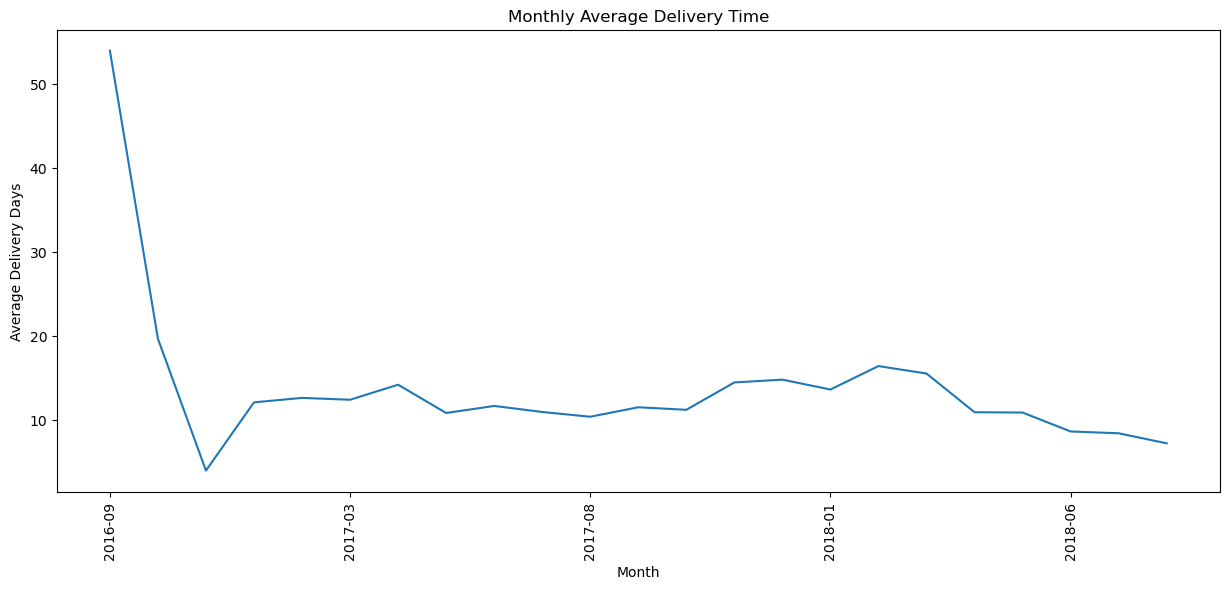

In [19]:
#8. Monthly Average Delivery Time
df["purchase_month"] = pd.to_datetime(
    df["order_purchase_timestamp"]
).dt.to_period("M").astype(str)

monthly_delivery = (
    df.groupby("purchase_month")["delivery_days"]
      .mean()
)
plt.figure(figsize=(15,6))
monthly_delivery.plot()
plt.title("Monthly Average Delivery Time")
plt.xlabel("Month")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=90)
plt.show()

1) Reveals seasonal variations in delivery performance.

2) Peaks may correspond to holiday seasons or promotional events.

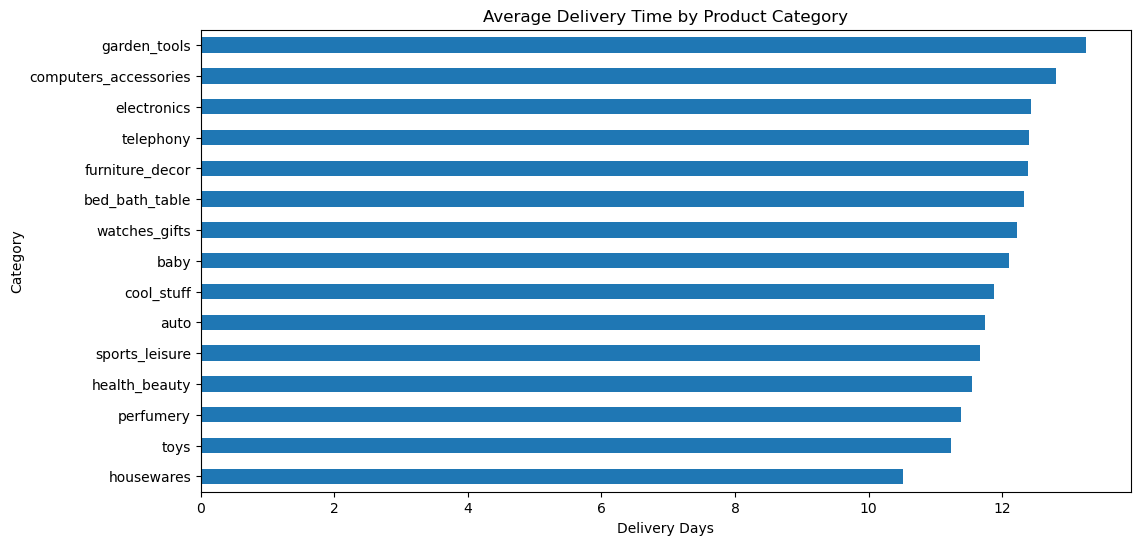

In [20]:
#9. Delivery Time by Product Category (Top 15)
top_categories = (
    df["product_category_name_english"]
    .value_counts()
    .head(15)
    .index
)
category_delivery = (
    df[df["product_category_name_english"].isin(top_categories)]
    .groupby("product_category_name_english")["delivery_days"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,6))
category_delivery.plot(kind="barh")
plt.title("Average Delivery Time by Product Category")
plt.xlabel("Delivery Days")
plt.ylabel("Category")
plt.show()

1) Bulky products such as furniture may take longer to deliver.

2) Smaller products like books have generally have shorter delivery times.

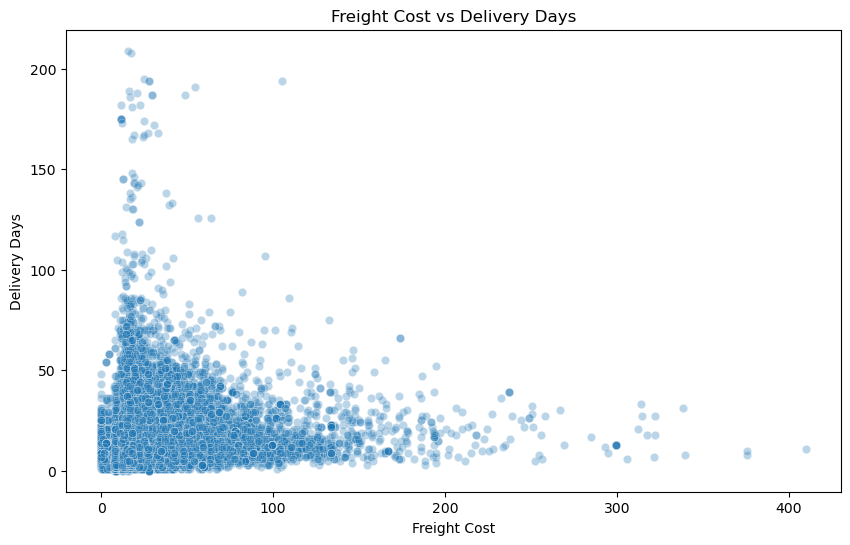

In [21]:
#10. Freight Cost vs Delivery Days
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="freight_value",
    y="delivery_days",
    data=df,
    alpha=0.3
)
plt.title("Freight Cost vs Delivery Days")
plt.xlabel("Freight Cost")
plt.ylabel("Delivery Days")
plt.show()

1) Higher freight charges do not necessarily guarantee faster delivery.

2) The weak relationship suggests other operational factors, such as distance and logistics networks, influence delivery speed.

##### Summary
1) Delivery consistency: Most orders are delivered within the expected timeframe, but delayed shipments form a long-tail distribution.

2) Regional performance: Some states consistently experience longer delivery times, indicating opportunities to optimize logistics.

3) Customer satisfaction: Delivery delays are associated with lower review scores, highlighting the importance of timely fulfillment.

4) Product characteristics: Delivery speed varies across product categories, likely due to differences in size, weight, and handling requirements.

5) Seasonality: Monthly trends can reveal periods of operational strain, supporting better resource planning during peak demand.